# Interpretable Machine Learning for Early Diabetes Risk Prediction Using Clinical Health Indicators

This notebook is the executable companion to the technical report in `reports/paper.md`.
It reproduces every figure and metric referenced in the paper, end to end, from a single
fixed random seed. It mirrors — and calls into — the modular pipeline in `src/`, so the
same logic used here is also unit-testable and reusable outside the notebook.

**Sections**
1. Setup
2. Data Loading & Cleaning
3. Exploratory Data Analysis
4. Train/Test Split & Leakage-Safe Imputation
5. Feature Engineering
6. Model Training (Logistic Regression, Random Forest, XGBoost)
7. Evaluation
8. Explainability (Feature Importance & SHAP)
9. AI Safety Reflection Checklist


## 1. Setup

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)
from xgboost import XGBClassifier

from preprocessing import (
    load_raw_data, replace_implausible_zeros_with_nan,
    impute_missing_median, missingness_report,
)
from feature_engineering import engineer_features

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Data Loading & Cleaning

The Pima Indians Diabetes Dataset (originally from the National Institute of Diabetes and
Digestive and Kidney Diseases, distributed publicly via UCI/Kaggle) contains 768 female
patients of Pima Indian heritage, age 21+, with 8 clinical features and a binary `Outcome`
label (1 = diabetes diagnosed within 5 years).

A key data-quality issue: several fields use `0` to represent a missing measurement
(e.g., a blood pressure of 0 mmHg is not physiologically possible). We convert those to
`NaN` explicitly rather than let the model learn from impossible values.


In [2]:
df_raw = load_raw_data("../data/diabetes.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
zero_report = missingness_report(df_raw)
print("Implausible zero (i.e. missing) counts per field:")
zero_report


Implausible zero (i.e. missing) counts per field:


Insulin          374
SkinThickness    227
BloodPressure     35
BMI               11
Glucose            5
dtype: int64

In [4]:
df_clean = replace_implausible_zeros_with_nan(df_raw)
df_clean.isna().sum()


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## 3. Exploratory Data Analysis

/tmp/ipykernel_655/1991034873.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])


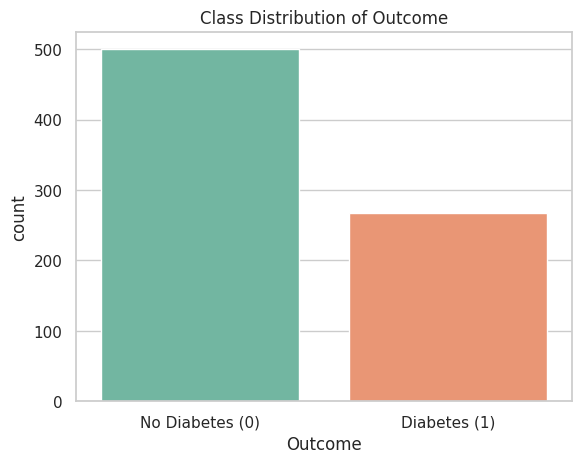

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [5]:
ax = sns.countplot(x="Outcome", data=df_raw, hue="Outcome", palette="Set2", legend=False)
ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])
plt.title("Class Distribution of Outcome")
plt.show()

print(df_raw["Outcome"].value_counts(normalize=True))


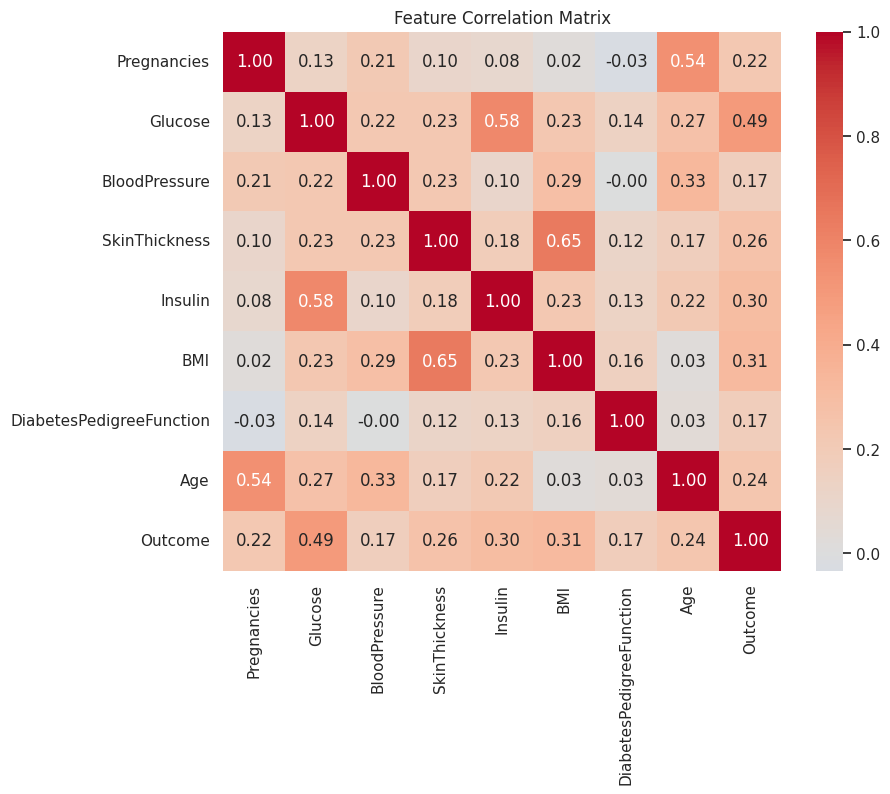

In [6]:
plt.figure(figsize=(9,7))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()


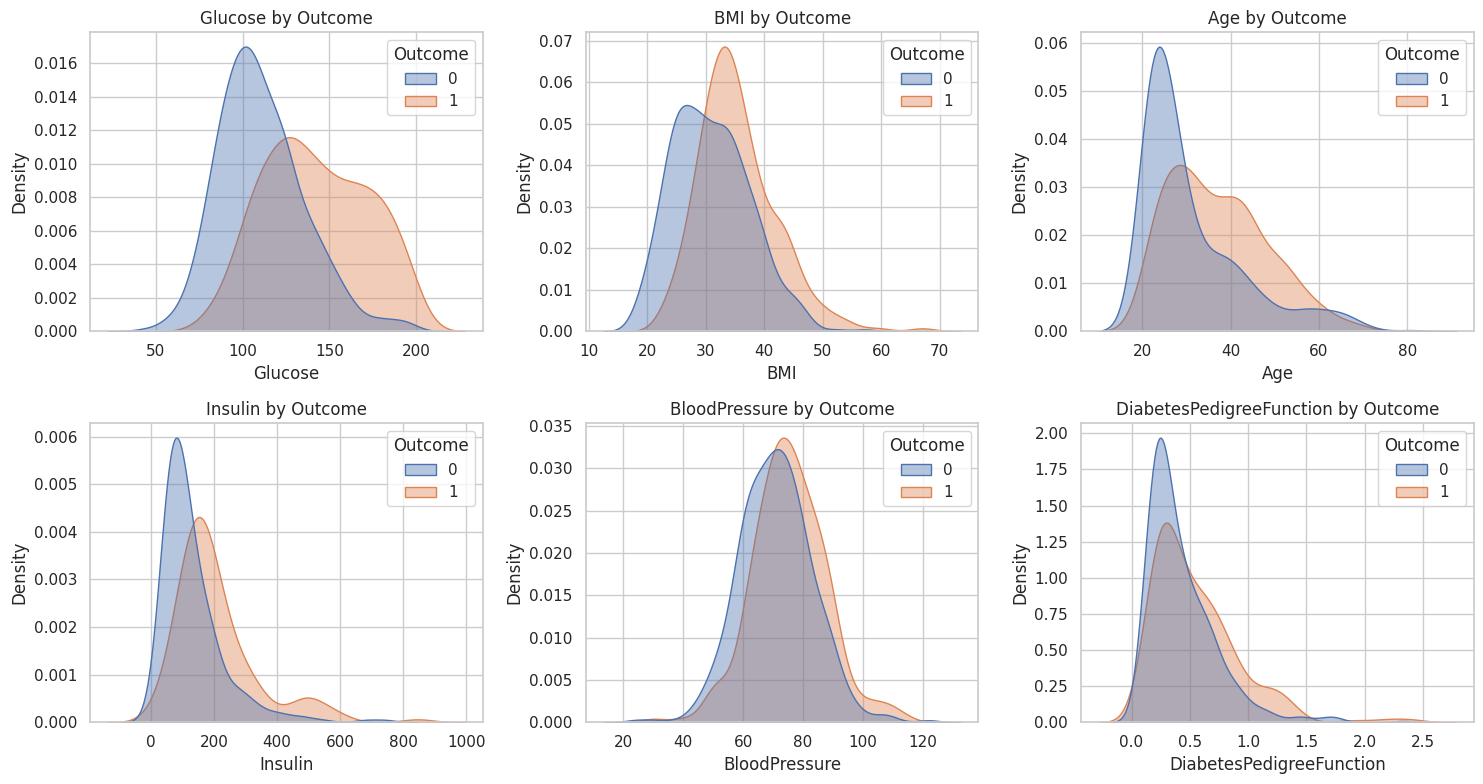

In [7]:
key_vars = ["Glucose", "BMI", "Age", "Insulin", "BloodPressure", "DiabetesPedigreeFunction"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, var in zip(axes.flatten(), key_vars):
    sns.kdeplot(data=df_clean, x=var, hue="Outcome", fill=True, common_norm=False, alpha=0.4, ax=ax)
    ax.set_title(f"{var} by Outcome")
plt.tight_layout()
plt.show()


## 4. Train/Test Split & Leakage-Safe Imputation

**Order matters.** We split into train/test *before* imputing missing values or engineering
features, and we fit the imputation medians and the `StandardScaler` on the training split
only. This avoids test-set statistics leaking into training — a subtle bug that inflates
reported performance and would misrepresent how the model performs on genuinely unseen
patients.


In [8]:
X_cols = [c for c in df_clean.columns if c != "Outcome"]
X = df_clean[X_cols]
y = df_clean["Outcome"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train_raw.shape, " Test:", X_test_raw.shape)


Train: (614, 8)  Test: (154, 8)


In [9]:
X_train_imp = impute_missing_median(X_train_raw, reference=X_train_raw)
X_test_imp = impute_missing_median(X_test_raw, reference=X_train_raw)  # medians from TRAIN only


## 5. Feature Engineering\n\nClinically motivated buckets and interaction terms — see `src/feature_engineering.py` for rationale on each feature.

In [10]:
train_fe = engineer_features(X_train_imp)
test_fe = engineer_features(X_test_imp)
train_fe, test_fe = train_fe.align(test_fe, join="left", axis=1, fill_value=0)

print("Engineered feature count:", train_fe.shape[1])
list(train_fe.columns)


Engineered feature count: 18


['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Glucose_BMI_Interaction',
 'Age_Pregnancies_Interaction',
 'BMI_Category_Normal',
 'BMI_Category_Overweight',
 'BMI_Category_Obese',
 'Glucose_Category_Prediabetic',
 'Glucose_Category_Diabetic_Range',
 'Age_Group_30-44',
 'Age_Group_45-59',
 'Age_Group_60+']

## 6. Model Training

In [11]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(train_fe), columns=train_fe.columns, index=train_fe.index)
X_test_scaled = pd.DataFrame(scaler.transform(test_fe), columns=test_fe.columns, index=test_fe.index)

log_reg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=5,
                             class_weight="balanced", random_state=RANDOM_STATE)
rf.fit(train_fe, y_train)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8,
                     scale_pos_weight=scale_pos_weight, eval_metric="logloss",
                     random_state=RANDOM_STATE)
xgb.fit(train_fe, y_train)

models = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Random Forest": (rf, test_fe),
    "XGBoost": (xgb, test_fe),
}
print("Trained:", list(models.keys()))


Trained: ['Logistic Regression', 'Random Forest', 'XGBoost']


## 7. Evaluation

In [12]:
results = {}
for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

metrics_df = pd.DataFrame(results).T
metrics_df.round(4)


,accuracy,precision,recall,f1_score,roc_auc
Logistic Regression,0.7922,0.6719,0.7963,0.7288,0.8465
Random Forest,0.7468,0.6119,0.7593,0.6777,0.8291
XGBoost,0.7468,0.6415,0.6296,0.6355,0.8331


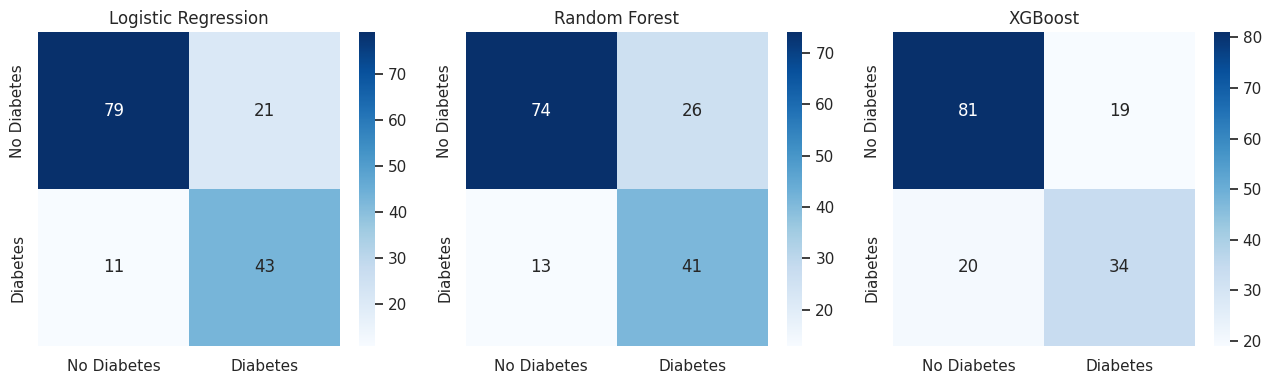

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, (model, X_te)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_te))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Diabetes","Diabetes"], yticklabels=["No Diabetes","Diabetes"], ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()


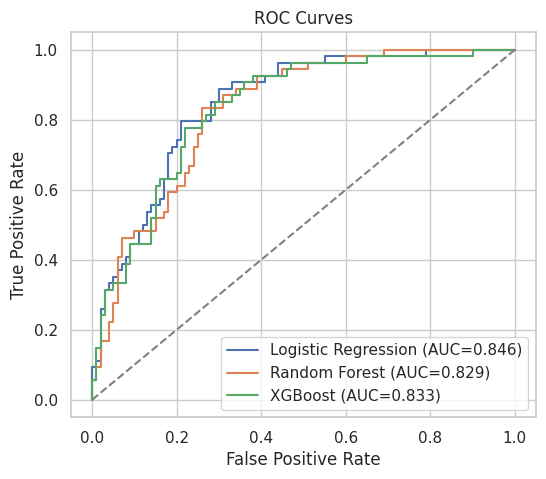

In [14]:
plt.figure(figsize=(6,5))
for name, (model, X_te) in models.items():
    y_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1], "--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend()
plt.show()


## 8. Explainability (Feature Importance & SHAP)

We use the Random Forest as the primary model for explanation because tree ensembles
support fast, exact SHAP values via `TreeExplainer`. Logistic Regression coefficients are
inspected separately since they are already directly interpretable (standardized log-odds).


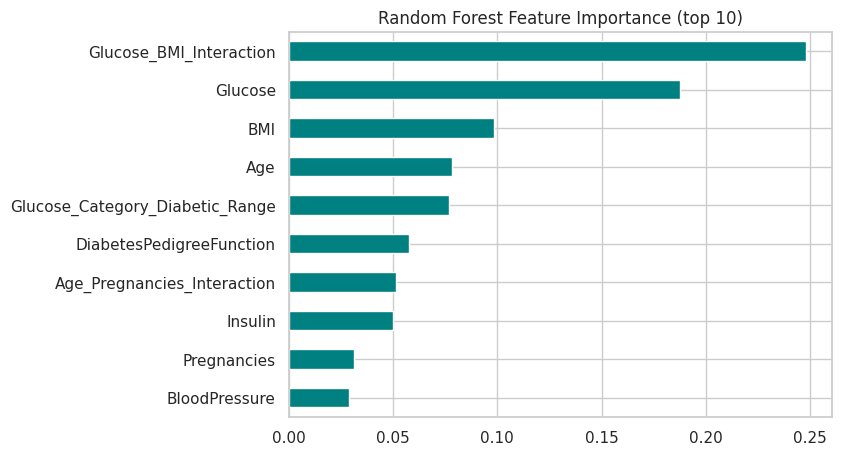

In [15]:
importances = pd.Series(rf.feature_importances_, index=train_fe.columns).sort_values(ascending=False)
importances.head(10).sort_values().plot(kind="barh", figsize=(7,5), color="teal")
plt.title("Random Forest Feature Importance (top 10)")
plt.show()


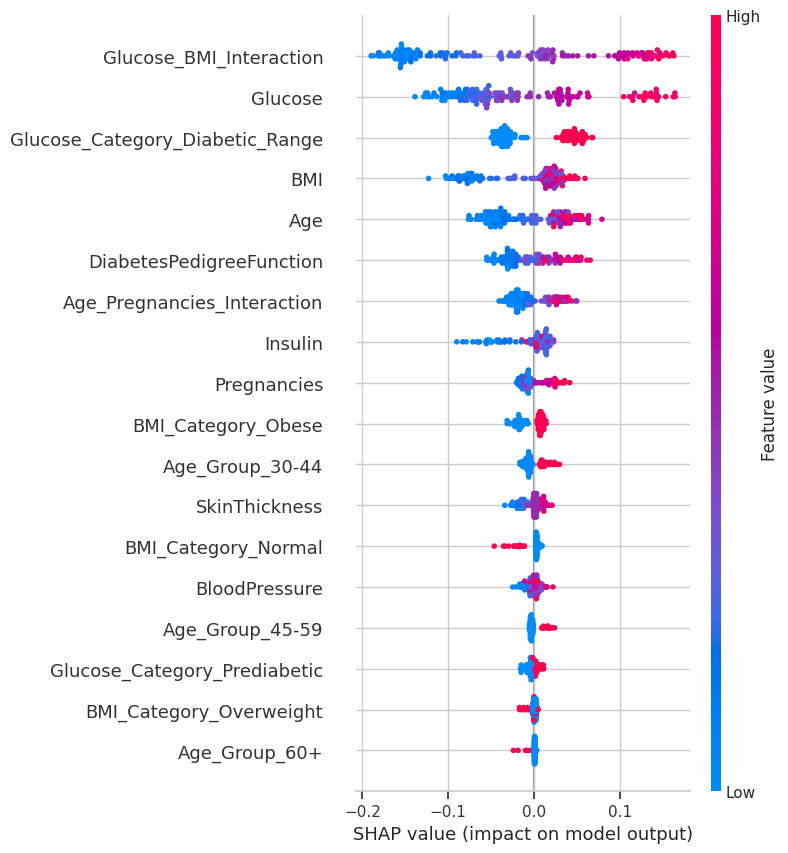

In [16]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(test_fe)
shap_vals_pos = shap_values[1] if isinstance(shap_values, list) else (
    shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values
)

shap.summary_plot(shap_vals_pos, test_fe)


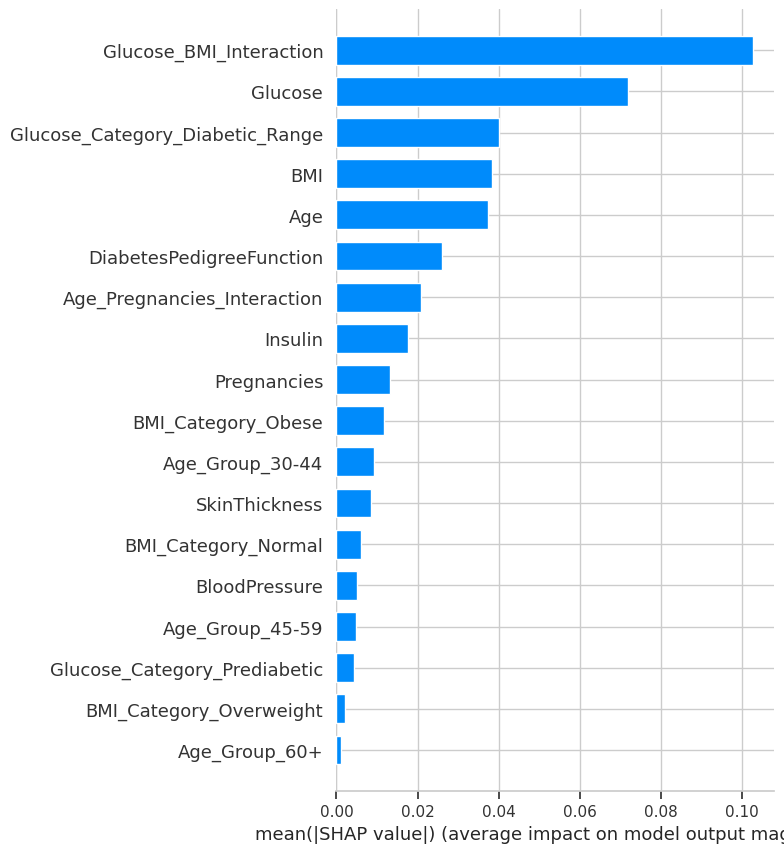

In [17]:
shap.summary_plot(shap_vals_pos, test_fe, plot_type="bar")


## 9. AI Safety Reflection Checklist

Before treating this model as anything more than a research prototype, a deployment-readiness
review should explicitly answer:

- **Bias & fairness** — Does the dataset population (Pima Indian women, 21+) generalize to the
  intended deployment population? No — using it on a broader population without revalidation
  risks systematically miscalibrated risk scores for groups not represented in training data.
- **Distribution shift** — Are the clinical measurement pipelines (e.g., how insulin is
  assayed) consistent between training data and the deployment site? Silent shift degrades
  calibration even if the model's code is unchanged.
- **Uncertainty** — Point predictions alone hide how confident the model is; predicted
  probabilities and calibration curves should accompany any score shown to a clinician.
- **Human oversight** — This model should support, not replace, clinical judgment; a
  high-risk score should trigger further testing (e.g., HbA1c, oral glucose tolerance test),
  not an automatic diagnosis.
- **Responsible deployment** — Any real deployment needs a monitoring plan for performance
  drift, a documented intended use statement, and a process for clinicians to report cases
  where the model's explanation does not match their clinical reasoning.

See `reports/paper.md`, Section "AI Safety Discussion," for the full treatment.
